In [ ]:
print("all ok")  # need to install ipykernel package

all ok


In [7]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [8]:
# if load_dotenv() fails to load the env vars, then this set of code will fix that

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing in your .env file")
if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY is missing in your .env file")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY

In [13]:
from langchain_openai import ChatOpenAI

In [14]:
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
chat_llm_op = chat_llm.invoke(input="Hello, how are you>?")
chat_llm_op

In [9]:
import re

def clean_response(text):
    return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()

### Configuring a LLM using ChatGroq and qwen3-32b model

In [10]:
from langchain_groq import ChatGroq

In [11]:
chat_llm = ChatGroq(
    model="qwen/qwen3-32b",
    groq_api_key=os.getenv("GROQ_API_KEY")
)

In [12]:
chat_llm_output = chat_llm.invoke(input="Hi, How are you?")
chat_llm_output

AIMessage(content='<think>\nOkay, the user greeted me with a simple "Hi, How are you?" and I need to respond. Let me think about the appropriate way to reply. First, I should acknowledge their greeting and express that I\'m doing well. Then, I should show interest in the user by asking how they\'re doing. I want to be friendly and open for conversation. Let me make sure my response is concise and natural-sounding. I should avoid any complex language since it\'s just a casual greeting. Alright, something like, "Hi there! I\'m doing well, thank you! How about you? I hope you\'re having a great day!" That sounds good. It\'s warm, acknowledges their greeting, and opens the door for them to share more if they\'d like.\n</think>\n\nHi there! I\'m doing well, thank you! How about you? I hope you\'re having a great day! 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 187, 'prompt_tokens': 14, 'total_tokens': 201, 'completion_time': 0.419018557, 'completion_tok

In [13]:
chat_llm_output.content

'<think>\nOkay, the user greeted me with a simple "Hi, How are you?" and I need to respond. Let me think about the appropriate way to reply. First, I should acknowledge their greeting and express that I\'m doing well. Then, I should show interest in the user by asking how they\'re doing. I want to be friendly and open for conversation. Let me make sure my response is concise and natural-sounding. I should avoid any complex language since it\'s just a casual greeting. Alright, something like, "Hi there! I\'m doing well, thank you! How about you? I hope you\'re having a great day!" That sounds good. It\'s warm, acknowledges their greeting, and opens the door for them to share more if they\'d like.\n</think>\n\nHi there! I\'m doing well, thank you! How about you? I hope you\'re having a great day! 😊'

In [14]:
res = clean_response(chat_llm_output.content)
res

"Hi there! I'm doing well, thank you! How about you? I hope you're having a great day! 😊"

### Defining the State

In [ ]:
from typing_extensions import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [61]:
# state
class GraphState(TypedDict):
    # message is acting as a `key`, and the list as the `value` 
    messages: Annotated[list[AnyMessage], operator.add]  # this will be a list of any messages and we can append as many as messages over here.

# using this state only, we are passing the input to diff diff nodes.


### Defining the Nodes

In [74]:
# this is our first node. what ever input will come to this node, it will generate a response regarding that input

def llm_call(state: GraphState) -> dict:
    """ Call the LLM using conversation messages and append AI response. """
    response = chat_llm.invoke(state["messages"])  # AIMessage

    return {
        "messages": [response]
    }

In [88]:
# another node: token counter.

def token_counter(state: GraphState) -> dict:
    """ Count tokens (simple word count) in the last AI message. """
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

### Orchestrating the above functions.. building Agentic Flow

In [76]:
from langgraph.graph import StateGraph

In [89]:
# Defining the state graph
builder = StateGraph(GraphState)  # using the StateGraph only, we can define our workflow, we can orchestrate our workflow

In [90]:
## defining nodes

builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [91]:
## adding edges
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

# in this way, we can orchestrate our workflow. we have normal edges, conditional edges, 

In [92]:
# compiling the graph
app = builder.compile()

In [93]:
app.get_graph()  # will give complete details about the graph/workflow

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

### Vizualizing the graph

In [94]:
from IPython.display import Image, display

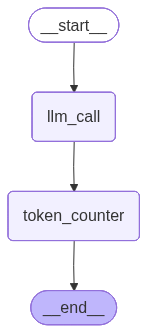

In [95]:
display(Image(app.get_graph().draw_mermaid_png()))

### Calling the entire workflow

In [96]:
# to call the entire workflow we have 2 methods:
# 1) with invoke()
# 2) with stream() and 
# 3) also async way

In [97]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is bunny. Say hello in detail")] 
})  # we are passing dict as an arg as, the state (StateGraph) is defined as the typeddict

In [98]:
result

{'messages': [HumanMessage(content='Hi, this is bunny. Say hello in detail', additional_kwargs={}, response_metadata={}),
  AIMessage(content='<think>\nOkay, the user is a cute little fluffy bunny named Bunny. I need to use a friendly and warm tone to express it. First, the greeting part needs to be lively and cheerful, such as "Hello, my little fluff ball!" to show the user\'s uniqueness.\n\nNext, I should consider the user\'s emotional needs. As a rabbit, they may like to be understood and accepted, so I need to use words that make them feel comfortable and relaxed. Words like "fluffy little softie" and "sweet little bunny" can help build a sense of closeness.\n\nIn addition, it is important to use some playful and vivid expressions to enhance the fun of the interaction. For example, "soft and fluffy little puffball" and "cute little fluffball" can make the dialogue more vivid and interesting. At the same time, using gestures such as "hopping around" and "flopping over" can add more 

In [99]:
for m in result["messages"]:
    print(type(m).__name__, ":", clean_response(m.content))

HumanMessage : Hi, this is bunny. Say hello in detail
AIMessage : Hello there, my little fluff ball! *hops around excitedly* Oh my, what a delight it is to meet you! I can see you're one of those soft and squishy bunnies who probably loves to nibble on carrots and floop around in the grass. *wags tail* You know what? I think we're going to be the best of friends!  

Let me introduce myself - I'm your friendly neighborhood helper, always ready to chat about anything under the sun. Whether you want to tell me about your latest carrot-hunting adventure or need help finding the coziest patch of sun to nap in, I'm all ears *and whiskers*! I've got a feeling you're going to make my day extra special with all your cute little bunny antics.  

What's on your mind today, my sweet little bunny? Are we going to have a hopping good time or a relaxing snuggle session? *twitches nose curiously* I'm up for either, just let me know what makes you happy!
AIMessage : Total token number in the generated 

### V-2 Tool calling 
#### creating tools 

In [1]:
from langchain_community.tools import WikipediaQueryRun  ## langchain comes with many inbuild tools. and one of which is wikipedia. we will use it in agentic workflow
from langchain_community.utilities import WikipediaAPIWrapper

In [3]:
# create an obj of wikipedia api wrapper
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [4]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [6]:
wiki_tool.run({"query": "Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

### Tool
Tool actually is a source/s where a llm can collect the context/data.
Anything could be a tool eg. wikipedia, youtube, weather info, calculator, website, api, own personal logic

Any basic service we can expose as a tool and we can give the access of that tool to llm, so that llm can get a context from that specific tool.

Tool: any service from where an LLM can collect the context/info/data .


Agentic Flow: LLM + Tool Calling + Memory + Planning

### Tool Calling: is very important as using the tool, we collect the important info. and provide it as a context to the LLM.

In [15]:
# 2) Tool - Tavily search
import os 
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [ ]:
tavily_tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

C:\Users\VamsheeTeja\AppData\Local\Temp\ipykernel_6932\709498164.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [ ]:
tavily_tool.invoke({"query": "How is the job market for ai engineering roles?"})

[{'title': 'What Is an AI Engineer? Job Market & Salary Guide (2025)',
  'url': 'https://intuitionlabs.ai/articles/ai-engineer-job-market-2025',
  'content': '# Conclusion\n\nAs of December 2025, the job market for AI engineers is robust and rapidly expanding. Demand for these specialists remains high across virtually all tech sectors, driven by widespread AI adoption and substantial corporate investment. Salaries are correspondingly elevated, and competition for qualified candidates is intense. While concerns exist about AI’s broader impact on employment, one clear consensus emerges from the data: AI engineering skills are among the most valuable and sought-after in today’s labor market. [...] Educationally, most AI engineers hold at least a bachelor’s degree in computer science, engineering, or related fields; many have advanced degrees. However, the field remains open to those who demonstrate skills via project experience or specialized training. In response to demand, both academic

In [20]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

In [21]:
search.invoke("what is the latest update on India vs Pakistan T20 world cup match?")

Impersonate 'firefox_109' does not exist, using 'random'


"India vs Pakistan , T 20 World Cup 2026: What to expect from the pitch in Colombo? India vs Pakistan , 27th Match , Group A. Qatar vs Bahrain, 5th T 20 I.Away from the Indian setup, Kishan spent long hours perfecting his off-side six-hitting and reverted to a bat grip that opened up new angles. ICC Men's T 20 world cup 2026. Over their last three T 20 World Cup meetings, Pakistan have a better collective batting average than India (28.26 vs 18.69) and have scored marginally quicker too (7.33 per over vs 7.28). Pakistan 's bowlers have taken 21 wickets to India 's 15. On net run rate, there's a pretty clear winner. The Indian cricket team beat Pakistan in its third T 20 World Cup 2026 Group A match and qualified for the Super 8 stage. Ishan Kishan scored 77. Tilak Varma sets tone for India vs Pakistan clash: ‘We are in the match zone’. Tilak Varma during a training session ahead of the ICC Men's T 20 World Cup 2026 match between India and Namibia.(PTI)."

In [23]:
search.invoke("What are the latest updates on iphone 17 release")

"3 days ago · The next iPhone update is here with new features for all users and key changes for those in the EU. Sep 9, 2025 · iPhone 17 will now be available starting with 256GB of storage — double the entry storage from the previous generation — and a 512GB option, in five beautiful colors: black, lavender, mist blue, sage, and white. Pre-orders begin Friday, September 12, with availability beginning Friday, September 19. We covered the Apple event below, and you can read our minute-by-minute account below of all of the company's announcements, along with updates as we get some hands-on time with the new phones... Apple’s iPhone 17 lineup is here. The tech giant has unveiled four new models that mark the latest editions to its marquee product. Sep 9, 2025 · September is the month of beginnings: a new school year, football season, TV shows. And it’s also when Apple drops a slew of new hardware, including its latest iPhones ."